In [66]:
#STAGE 1 — Data Cleaning
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Data_Sheet_Ground_Water.csv")
# Inspect
print(df.shape)
df.head(2)

(42, 20)


,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),BOD(ppm),DO(ppm),Lead(ppm),Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l)
0,Karan Lake (Site 1) (Ground Water),2016,7.5,NO,0.4,246.0,112.4,65.0,0.4,23.0,16.02,6.2,ND,0.3,45.0,ND,ND,3000,200,ND
1,Karan Lake (Site 1) (Ground Water),2017,7.7,NO,0.5,276.0,122.0,76.0,0.5,23.5,16.40,6.0,ND,0.4,45.0,ND,ND,3000,200,ND


In [67]:
import pandas as pd
import numpy as np

# 1. Load raw Excel
raw = pd.read_csv("Data_Sheet_Ground_Water.csv", header=0)

print("Raw shape:", raw.shape)
print(raw.head())

# 2. Clean column names
raw.columns = (
    raw.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# 3. Mandatory identifier columns
required_cols = ['site', 'year']
for col in required_cols:
    if col not in raw.columns:
        raise ValueError(f"Missing required column: {col}")

# 4. Drop completely empty rows
raw = raw.dropna(how='all')

# 5. Fix YEAR column
raw['year'] = pd.to_numeric(raw['year'], errors='coerce')
raw = raw.dropna(subset=['year'])
raw['year'] = raw['year'].astype(int)

# 6. PROTECT SITE COLUMN (CRITICAL)
raw['site'] = raw['site'].astype(str).str.strip()

# 7. Identify numeric measurement columns ONLY
numeric_cols = [
    col for col in raw.columns
    if col not in ['site', 'year']
]

# 8. Detection-limit handling (ONLY numeric columns)
raw[numeric_cols] = raw[numeric_cols].replace(
    ['NO', 'ND', 'nd', 'no', '-'], np.nan
)

# 9. Convert numeric columns safely
for col in numeric_cols:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# 10. Remove rows with too much missing numeric data
threshold = int(0.7 * len(numeric_cols))  # keep rows with ≥30% data
clean = raw.dropna(subset=numeric_cols, thresh=threshold)

# 11. Final sanity check
print("\nCleaned shape:", clean.shape)
print(clean.head())
print("\nMissing values per column:")
print(clean.isna().sum())

# 12. Save CLEAN dataset
clean.to_csv("groundwater_cleaned.csv", index=False)
print("\n Clean dataset saved as groundwater_cleaned.csv")


Raw shape: (42, 20)
                                     Site  Year    pH Odour  Turbidity  \
0      Karan Lake (Site 1) (Ground Water)  2016  7.50    NO       0.40   
1      Karan Lake (Site 1) (Ground Water)  2017  7.70    NO       0.50   
2      Karan Lake (Site 1) (Ground Water)  2018  7.90    NO       0.60   
3  Brahma Sarovar(Site 2) (Ground Water )  2016  7.61    NO       0.20   
4  Brahma Sarovar(Site 2) (Ground Water )  2017  7.60    NO       0.21   

   Conductivity  Chloride (ppm)  Sulphates(ppm)  Iron (ppm)  COD(ppm)  \
0         246.0           112.4            65.0         0.4      23.0   
1         276.0           122.0            76.0         0.5      23.5   
2         296.0           129.9            93.0         0.6      24.8   
3         294.0           121.9            60.0         0.5      31.3   
4         300.0           121.8            60.0         0.7      34.2   

   BOD(ppm)  DO(ppm) Lead(ppm)  Ammonia(ppm)  Nitrate(ppm) Fluorides(ppm)  \
0     16.02      6.

C:\Users\jaswa\AppData\Local\Temp\ipykernel_20156\3003968772.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  raw[numeric_cols] = raw[numeric_cols].replace(



Cleaned shape: (42, 20)
                                     site  year    ph  odour  turbidity  \
0      Karan Lake (Site 1) (Ground Water)  2016  7.50    NaN       0.40   
1      Karan Lake (Site 1) (Ground Water)  2017  7.70    NaN       0.50   
2      Karan Lake (Site 1) (Ground Water)  2018  7.90    NaN       0.60   
3  Brahma Sarovar(Site 2) (Ground Water )  2016  7.61    NaN       0.20   
4  Brahma Sarovar(Site 2) (Ground Water )  2017  7.60    NaN       0.21   

   conductivity  chloride_(ppm)  sulphates(ppm)  iron_(ppm)  cod(ppm)  \
0         246.0           112.4            65.0         0.4      23.0   
1         276.0           122.0            76.0         0.5      23.5   
2         296.0           129.9            93.0         0.6      24.8   
3         294.0           121.9            60.0         0.5      31.3   
4         300.0           121.8            60.0         0.7      34.2   

   bod(ppm)  do(ppm)  lead(ppm)  ammonia(ppm)  nitrate(ppm)  fluorides(ppm)  \
0     

In [68]:
#Convert everything to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with too many missing values
df = df.dropna(thresh=int(0.7 * len(df.columns)))

print(df.isna().sum())

Site                              33
Year                               0
pH                                 0
Odour                             33
Turbidity                          0
Conductivity                       0
Chloride (ppm)                     0
Sulphates(ppm)                     0
Iron (ppm)                         0
COD(ppm)                           0
BOD(ppm)                           0
DO(ppm)                            0
Lead(ppm)                         33
Ammonia(ppm)                       0
Nitrate(ppm)                       0
Fluorides(ppm)                    18
Phosphates(ppm)                   27
Total Bacterial Count (cfu/ml)     0
Total Fungal Count (cfu/ml)        9
Pesticide (µg/l)                  33
dtype: int64


In [69]:
clean['site'].unique()

array(['Karan Lake (Site 1) (Ground Water)',
       'Brahma Sarovar(Site 2) (Ground Water )',
       'Teekar Taal(Site 3) (Ground Water)',
       'Agra Canal(Site 1) (Ground Water)',
       'Yamuna River(Site 1) (Ground Water)',
       'Yamuna River(Site 2) (Ground Water)',
       'Yamuna River(Site 3) (Ground Water)',
       'Yamuna River(Site 4) (Ground Water)',
       'Ghaggar River(Site 1) (Ground Water)',
       'Ghaggar River(Site 2) (Ground Water)',
       'Ghaggar River(Site 3) (Ground Water)',
       'Ghaggar River(Site 4) (Ground Water)',
       'Ghaggar River(Site 5) (Ground Water)',
       'Markanda River(Site 1) (Ground Water)'], dtype=object)

In [70]:
#unit harmonization
df= clean.copy()
if "iron" in df.columns:
    df["iron"] = df["iron"] / 1000  # µg/L → mg/L

In [71]:
#detection limit handling
detection_limits = {
    "iron": 0.01,
    "fluoride": 0.1,
    "nitrate": 0.5
}
for p, dl in detection_limits.items():
    if p in df.columns:
        df[p] = df[p].clip(lower=dl/2)

In [72]:
#outliner handling
domain_limits = {
    "ph": (6.5, 8.5),
    "tds": (0, 2000),
    "nitrate": (0, 100)
}

for p, (lo, hi) in domain_limits.items():
    if p in df.columns:
        df.loc[(df[p] < lo) | (df[p] > hi), p] = np.nan

In [73]:
#missing data control
id_cols = ['site','year']
numeric_cols = df.columns.difference(id_cols)

df = df.dropna(subset = numeric_cols,thresh=int(0.7*len(numeric_cols)))

In [74]:
#save the output
df.to_csv("gw_sanity.csv", index=False)

In [75]:
#2. GROUND WATER WQI
#Purpose:
#1. Parameter standardization
#2. Sub-index
#3. Weighted aggregation
#4. Class assignment
#LOAD:
import pandas as pd
import numpy as np
df = pd.read_csv("gw_sanity.csv")

In [76]:
df.head(5)

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l)
0,Karan Lake (Site 1) (Ground Water),2016,7.50,NaN,0.40,246.0,112.4,65.0,0.4,23.0,16.02,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN
1,Karan Lake (Site 1) (Ground Water),2017,7.70,NaN,0.50,276.0,122.0,76.0,0.5,23.5,16.40,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN
2,Karan Lake (Site 1) (Ground Water),2018,7.90,NaN,0.60,296.0,129.9,93.0,0.6,24.8,17.80,5.9,NaN,0.6,45.0,NaN,NaN,3000,200.0,NaN
3,Brahma Sarovar(Site 2) (Ground Water ),2016,7.61,NaN,0.20,294.0,121.9,60.0,0.5,31.3,19.20,7.2,NaN,0.3,45.0,NaN,NaN,800,NaN,NaN
4,Brahma Sarovar(Site 2) (Ground Water ),2017,7.60,NaN,0.21,300.0,121.8,60.0,0.7,34.2,20.20,6.2,NaN,0.3,51.0,NaN,NaN,900,NaN,NaN


In [77]:
print(clean.columns.tolist())

['site', 'year', 'ph', 'odour', 'turbidity', 'conductivity', 'chloride_(ppm)', 'sulphates(ppm)', 'iron_(ppm)', 'cod(ppm)', 'bod(ppm)', 'do(ppm)', 'lead(ppm)', 'ammonia(ppm)', 'nitrate(ppm)', 'fluorides(ppm)', 'phosphates(ppm)', 'total_bacterial_count_(cfu/ml)', 'total_fungal_count_(cfu/ml)', 'pesticide_(µg/l)']


In [78]:
#STANDARD AND WEIGHTS
param_map={
    'ph':'ph',
    'turbidity':'turbidity',
    'chloride':'chloride_(ppm)',
    'sulphate':'sulphates(ppm)',
    'nitrate':'nitrate(ppm)',
    'iron':'iron_(ppm)',
    'fluoride':'fluorides(ppm)',
    'conductivity':'conductiv'
}
#replaced standards with bis_limits:
def compute_bis_wqi(df):
    bis_limits= {
    "ph":(6.5,8.5),
    "turbidity":5,
    "chloride": 250,
    "sulphate": 200,
    "nitrate": 45,
    "fluoride": 1.5,
    "iron": 0.3,
    "conductivity": 2000
}

    weights = {k: 1/v if not isinstance(v, tuple) else 1/v[1]
               for k, v in bis_limits.items()}
    wqi_vals = []
    for _, row in df.iterrows():
        num, den = 0, 0

        for p, limit in bis_limits.items():
            col = param_map[p]
            if col not in df.columns or pd.isna(row[col]):
                continue

            wi = weights[p]

            if p == 'ph':
                qi = abs(row[col] - 7.0) / (8.5 - 7.0) * 100
            else:
                qi = (row[col] / limit) * 100

            num += wi * qi
            den += wi

        wqi_vals.append(num / den if den != 0 else np.nan)

    df['wqi'] = wqi_vals
    return df

In [79]:
df_wqi= clean.copy()
df_wqi= compute_bis_wqi(df_wqi)

In [80]:
#CLASS ASSIGNMENT
def wqi_class(wqi):
    if wqi <= 50: 
        return "Excellent"
    elif wqi <= 100:
        return "Good"
    elif wqi <= 200: 
        return "Poor"
    elif wqi <= 300: 
        return "Very Poor"
    else:
        return "Unsuitable"

df_wqi['wqi_class'] = df_wqi['wqi'].apply(wqi_class)

In [81]:
#SANITY CHECK- IMPORTANT
df_wqi['wqi'].describe()

count      42.000000
mean      353.412593
std       498.376748
min        61.700975
25%       152.285464
50%       183.823259
75%       323.389226
max      2354.166846
Name: wqi, dtype: float64

In [82]:
df_wqi[['ph','chloride_(ppm)','wqi']].head()

,ph,chloride_(ppm),wqi
0,7.50,112.4,122.896707
1,7.70,122.0,153.618156
2,7.90,129.9,184.342939
3,7.61,121.9,153.089656
4,7.60,121.8,213.509994


In [83]:
#SAVE THE OUTPUT
df_wqi['wqi_class'] = df_wqi['wqi'].apply(wqi_class)
df_wqi.to_csv("gw_wqi.csv", index=False)

In [84]:
df_wqi.head(3)

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l),wqi,wqi_class
0,Karan Lake (Site 1) (Ground Water),2016,7.5,NaN,0.4,246.0,112.4,65.0,0.4,23.0,16.02,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN,122.896707,Poor
1,Karan Lake (Site 1) (Ground Water),2017,7.7,NaN,0.5,276.0,122.0,76.0,0.5,23.5,16.40,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN,153.618156,Poor
2,Karan Lake (Site 1) (Ground Water),2018,7.9,NaN,0.6,296.0,129.9,93.0,0.6,24.8,17.80,5.9,NaN,0.6,45.0,NaN,NaN,3000,200.0,NaN,184.342939,Poor


In [85]:
#SUB-INDEX+AGGREGATION
#def wqi(row):
 #   score = 0
  #  for p in standards:
   #     if p in row and not np.isnan(row[p]):
    #        qi = (row[p] / standards[p]) * 100
     #       score += qi * weights[p]
    #return score / W

#df["wqi"] = df.apply(wqi, axis=1)

In [86]:
#3. ML Modeling
#Purpose:
#Regression → WQI
#Classification → class
#Feature importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import pandas as pd

df = pd.read_csv("gw_wqi.csv")
standards = {
    "ph": 8.5,
    
    "chloride_(ppm)": 250,
    "sulphates(ppm)": 200,
    "nitrate(ppm)": 45,
    "fluorides(ppm)": 1.5,
    "iron_(ppm)": 0.3
}

X = df[list(standards.keys())]
y_reg = df["wqi"]
y_cls = df["wqi_class"]

In [87]:
#Regression
#Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.2)

#reg = RandomForestRegressor(n_estimators=300)
#reg.fit(Xtr, ytr)

RandomForestRegressor(n_estimators=300)

In [88]:
#Classification
cls = RandomForestClassifier(n_estimators=300)
cls.fit(Xtr, y_cls.loc[Xtr.index])

RandomForestClassifier(n_estimators=300)

In [89]:
#Feature Importance
importance = pd.Series(reg.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

iron_(ppm)        0.369745
sulphates(ppm)    0.287155
nitrate(ppm)      0.204343
fluorides(ppm)    0.125559
chloride_(ppm)    0.010270
ph                0.002928
dtype: float64

In [90]:
#save
df["predicted_wqi"] = reg.predict(X)
df.to_csv("gw_ml_outputs.csv", index=False)

In [91]:
#4. Spatial Intelligence: the ability to visualize, manipulate, and understand objects and spaces in three dimensions.

df["priority_score"] = df["wqi"] * 1.0  # exposure proxy placeholder
df.to_csv("gw_spatial_scores.csv", index=False)

In [92]:
#5. Health Risk Abstraction
#Rule-based. No causation lies.
def risk_flag(wqi):
    if wqi > 300: return "High"
    if wqi > 150: return "Moderate"
    return "Low"

df["relative_health_risk"] = df["wqi"].apply(risk_flag)
df.to_csv("gw_risk_index.csv", index=False)

In [93]:
#6. Alerts
df["alert"] = df["wqi"] > 200

In [94]:
df.head(4)

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l),wqi,wqi_class,predicted_wqi,priority_score,relative_health_risk,alert
0,Karan Lake (Site 1) (Ground Water),2016,7.50,NaN,0.4,246.0,112.4,65.0,0.4,23.0,16.02,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN,122.896707,Poor,120.330619,122.896707,Low,False
1,Karan Lake (Site 1) (Ground Water),2017,7.70,NaN,0.5,276.0,122.0,76.0,0.5,23.5,16.40,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN,153.618156,Poor,152.435414,153.618156,Moderate,False
2,Karan Lake (Site 1) (Ground Water),2018,7.90,NaN,0.6,296.0,129.9,93.0,0.6,24.8,17.80,5.9,NaN,0.6,45.0,NaN,NaN,3000,200.0,NaN,184.342939,Poor,184.189344,184.342939,Moderate,False
3,Brahma Sarovar(Site 2) (Ground Water ),2016,7.61,NaN,0.2,294.0,121.9,60.0,0.5,31.3,19.20,7.2,NaN,0.3,45.0,NaN,NaN,800,NaN,NaN,153.089656,Poor,152.744731,153.089656,Moderate,False


In [95]:
df.head()

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l),wqi,wqi_class,predicted_wqi,priority_score,relative_health_risk,alert
0,Karan Lake (Site 1) (Ground Water),2016,7.50,NaN,0.40,246.0,112.4,65.0,0.4,23.0,16.02,6.2,NaN,0.3,45.0,NaN,NaN,3000,200.0,NaN,122.896707,Poor,120.330619,122.896707,Low,False
1,Karan Lake (Site 1) (Ground Water),2017,7.70,NaN,0.50,276.0,122.0,76.0,0.5,23.5,16.40,6.0,NaN,0.4,45.0,NaN,NaN,3000,200.0,NaN,153.618156,Poor,152.435414,153.618156,Moderate,False
2,Karan Lake (Site 1) (Ground Water),2018,7.90,NaN,0.60,296.0,129.9,93.0,0.6,24.8,17.80,5.9,NaN,0.6,45.0,NaN,NaN,3000,200.0,NaN,184.342939,Poor,184.189344,184.342939,Moderate,False
3,Brahma Sarovar(Site 2) (Ground Water ),2016,7.61,NaN,0.20,294.0,121.9,60.0,0.5,31.3,19.20,7.2,NaN,0.3,45.0,NaN,NaN,800,NaN,NaN,153.089656,Poor,152.744731,153.089656,Moderate,False
4,Brahma Sarovar(Site 2) (Ground Water ),2017,7.60,NaN,0.21,300.0,121.8,60.0,0.7,34.2,20.20,6.2,NaN,0.3,51.0,NaN,NaN,900,NaN,NaN,213.509994,Very Poor,220.859224,213.509994,Moderate,True


In [96]:
#MAPPING can be done in gw_wqi.csv and gw_spatial because, Maps DO NOT go in WQI or ML notebooks.
import pandas as pd
import geopandas as gpd
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

In [97]:
df = pd.read_csv("gw_wqi.csv")

In [98]:
df.shape

(42, 22)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   site                            42 non-null     object 
 1   year                            42 non-null     int64  
 2   ph                              42 non-null     float64
 3   odour                           0 non-null      float64
 4   turbidity                       42 non-null     float64
 5   conductivity                    42 non-null     float64
 6   chloride_(ppm)                  42 non-null     float64
 7   sulphates(ppm)                  42 non-null     float64
 8   iron_(ppm)                      42 non-null     float64
 9   cod(ppm)                        42 non-null     float64
 10  bod(ppm)                        42 non-null     float64
 11  do(ppm)                         42 non-null     float64
 12  lead(ppm)                       0 non-

In [100]:
import pandas as pd
pd.set_option("display.max_rows",200)
pd.set_option("display.max_columns",None)
pd.set_option("display.width",None)
df

,site,year,ph,odour,turbidity,conductivity,chloride_(ppm),sulphates(ppm),iron_(ppm),cod(ppm),bod(ppm),do(ppm),lead(ppm),ammonia(ppm),nitrate(ppm),fluorides(ppm),phosphates(ppm),total_bacterial_count_(cfu/ml),total_fungal_count_(cfu/ml),pesticide_(µg/l),wqi,wqi_class
0,Karan Lake (Site 1) (Ground Water),2016,7.50,NaN,0.40,246.0,112.40,65.0,0.40,23.00,16.02,6.2,NaN,0.30,45.0,NaN,NaN,3000,200.0,NaN,122.896707,Poor
1,Karan Lake (Site 1) (Ground Water),2017,7.70,NaN,0.50,276.0,122.00,76.0,0.50,23.50,16.40,6.0,NaN,0.40,45.0,NaN,NaN,3000,200.0,NaN,153.618156,Poor
2,Karan Lake (Site 1) (Ground Water),2018,7.90,NaN,0.60,296.0,129.90,93.0,0.60,24.80,17.80,5.9,NaN,0.60,45.0,NaN,NaN,3000,200.0,NaN,184.342939,Poor
3,Brahma Sarovar(Site 2) (Ground Water ),2016,7.61,NaN,0.20,294.0,121.90,60.0,0.50,31.30,19.20,7.2,NaN,0.30,45.0,NaN,NaN,800,NaN,NaN,153.089656,Poor
4,Brahma Sarovar(Site 2) (Ground Water ),2017,7.60,NaN,0.21,300.0,121.80,60.0,0.70,34.20,20.20,6.2,NaN,0.30,51.0,NaN,NaN,900,NaN,NaN,213.509994,Very Poor
5,Brahma Sarovar(Site 2) (Ground Water ),2018,7.70,NaN,0.30,314.0,122.90,60.0,0.70,34.20,21.20,6.0,NaN,0.30,55.0,NaN,NaN,900,NaN,NaN,213.874886,Very Poor
6,Teekar Taal(Site 3) (Ground Water),2016,7.50,NaN,0.20,513.0,19.35,75.0,0.50,24.00,12.80,7.0,NaN,0.50,10.0,NaN,NaN,15000,1200.0,NaN,152.351587,Poor
7,Teekar Taal(Site 3) (Ground Water),2017,7.53,NaN,0.30,543.0,27.35,78.0,0.59,25.40,13.00,6.0,NaN,0.60,13.0,NaN,NaN,16000,1200.0,NaN,179.727523,Poor
8,Teekar Taal(Site 3) (Ground Water),2018,7.60,NaN,0.30,565.0,32.35,88.0,0.60,26.40,13.60,6.1,NaN,0.70,14.0,NaN,NaN,17000,1300.0,NaN,182.916514,Poor
9,Agra Canal(Site 1) (Ground Water),2016,7.20,NaN,0.50,453.0,266.50,95.0,0.20,15.10,7.30,6.3,NaN,0.30,15.0,NaN,NaN,2000,100.0,NaN,61.700975,Good


In [101]:
df.head()
df.info()
df[['site', 'year', 'wqi']].dropna().head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   site                            42 non-null     object 
 1   year                            42 non-null     int64  
 2   ph                              42 non-null     float64
 3   odour                           0 non-null      float64
 4   turbidity                       42 non-null     float64
 5   conductivity                    42 non-null     float64
 6   chloride_(ppm)                  42 non-null     float64
 7   sulphates(ppm)                  42 non-null     float64
 8   iron_(ppm)                      42 non-null     float64
 9   cod(ppm)                        42 non-null     float64
 10  bod(ppm)                        42 non-null     float64
 11  do(ppm)                         42 non-null     float64
 12  lead(ppm)                       0 non-

,site,year,wqi
0,Karan Lake (Site 1) (Ground Water),2016,122.896707
1,Karan Lake (Site 1) (Ground Water),2017,153.618156
2,Karan Lake (Site 1) (Ground Water),2018,184.342939
3,Brahma Sarovar(Site 2) (Ground Water ),2016,153.089656
4,Brahma Sarovar(Site 2) (Ground Water ),2017,213.509994


In [102]:
#PLOTTING

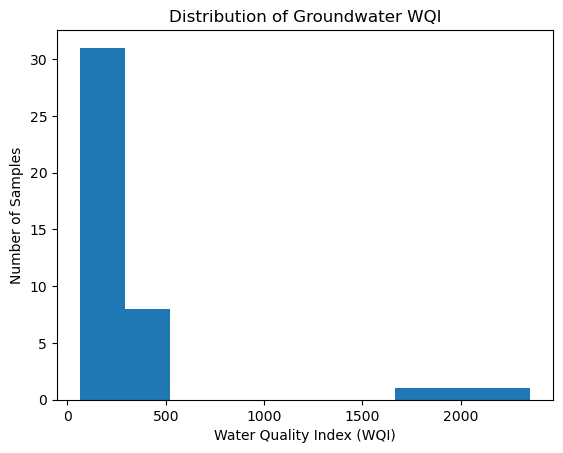

In [103]:
#WQI DISTRIBUTION
# It tells how good or bad is groundwater overall.
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure()
plt.hist(df['wqi'].dropna(), bins=10)
plt.xlabel('Water Quality Index (WQI)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Groundwater WQI')
plt.show()

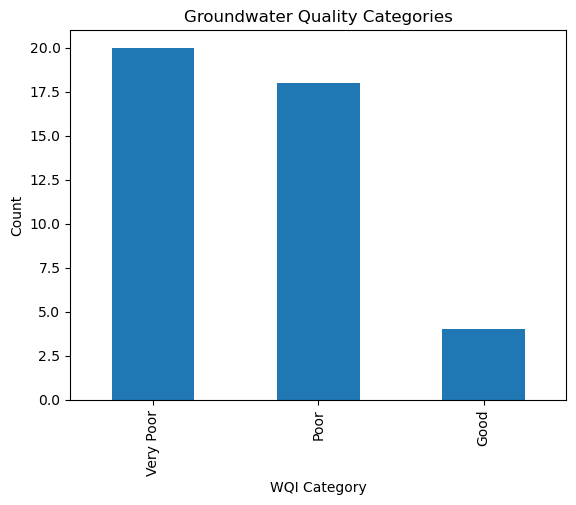

In [104]:
#WQI CLASSIFICATION
#creating categories
def wqi_class(wqi):
    if wqi <= 50:
        return 'Excellent'
    elif wqi <= 100:
        return 'Good'
    elif wqi <= 200:
        return 'Poor'
    else:
        return 'Very Poor'

df['wqi_class'] = df['wqi'].apply(wqi_class)

#Plotting
plt.figure()
df['wqi_class'].value_counts().plot(kind='bar')
plt.xlabel('WQI Category')
plt.ylabel('Count')
plt.title('Groundwater Quality Categories')
plt.show()

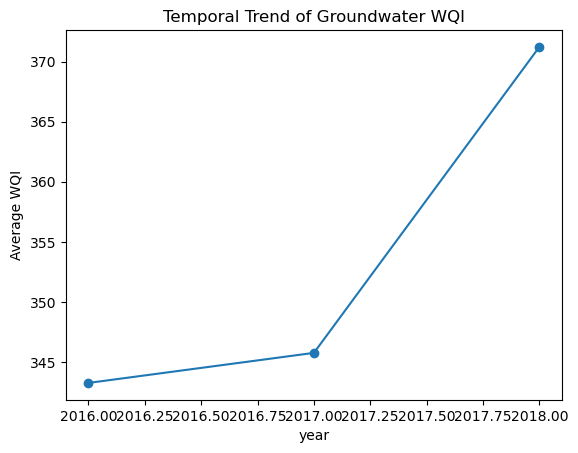

In [105]:
#Is groundwater improving or degrading?
#Trend Analysis(WQI vs Year)
yearly_wqi = df.groupby('year')['wqi'].mean()

plt.figure()
plt.plot(yearly_wqi.index, yearly_wqi.values, marker='o')
plt.xlabel('year')
plt.ylabel('Average WQI')
plt.title('Temporal Trend of Groundwater WQI')
plt.show()

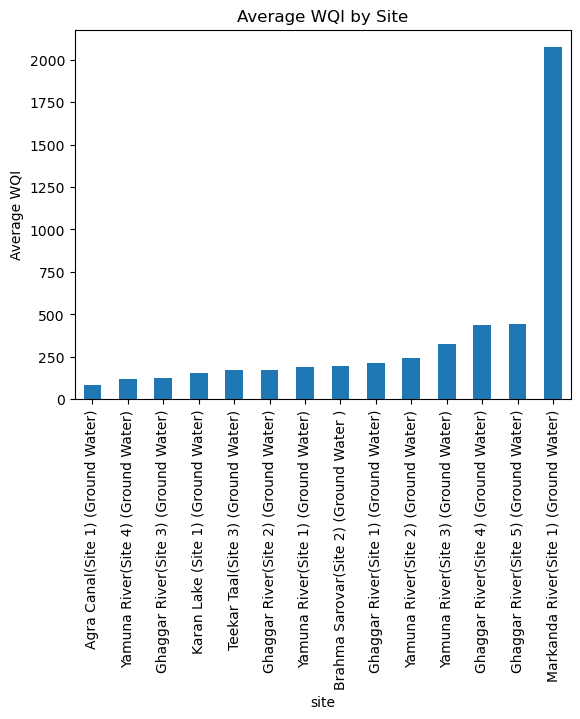

In [106]:
#Which city is most polluted?
#SITE-WISE WQI COMPARISON
site_wqi = df.groupby('site')['wqi'].mean().sort_values()

plt.figure()
site_wqi.plot(kind='bar')
plt.xlabel('site')
plt.ylabel('Average WQI')
plt.title('Average WQI by Site')
plt.show()

In [107]:
df[['site', 'wqi']].head()
df[['site', 'wqi']].isna().sum()

site    0
wqi     0
dtype: int64

In [108]:
df.columns = df.columns.str.strip().str.lower()
site_wqi = (
    df.groupby('site')['wqi']
      .mean()
      .sort_values()
)

<Figure size 640x480 with 0 Axes>

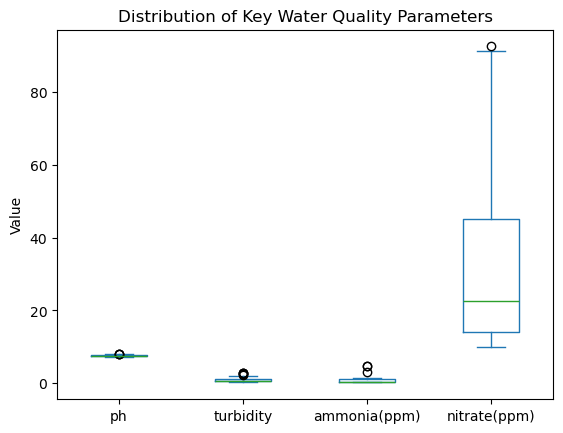

In [109]:
#Which parameter is most dangerous?
#Parameter behaviour
parameters = ['ph', 'turbidity', 'ammonia(ppm)', 'nitrate(ppm)']
plt.figure()
df[parameters].plot(kind='box')
plt.ylabel('Value')
plt.title('Distribution of Key Water Quality Parameters')
plt.show()

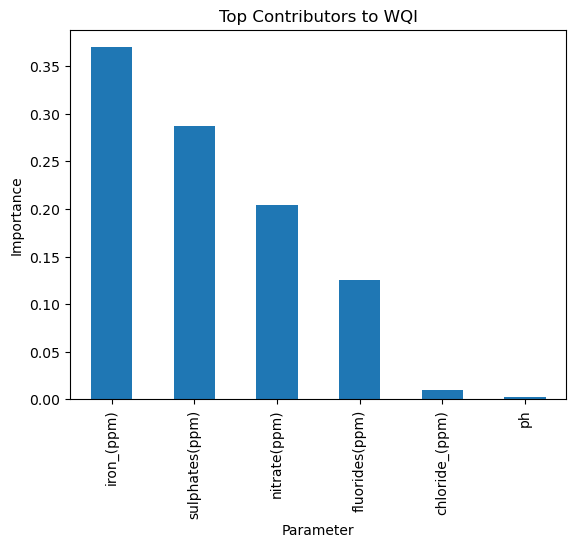

In [110]:
#Feature Importance
import pandas as pd

importance = pd.Series(
    reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
importance.head(20).plot(kind='bar')
plt.xlabel('Parameter')
plt.ylabel('Importance')
plt.title('Top Contributors to WQI')
plt.show()

In [111]:
print(df_wqi.columns)

Index(['site', 'year', 'ph', 'odour', 'turbidity', 'conductivity',
       'chloride_(ppm)', 'sulphates(ppm)', 'iron_(ppm)', 'cod(ppm)',
       'bod(ppm)', 'do(ppm)', 'lead(ppm)', 'ammonia(ppm)', 'nitrate(ppm)',
       'fluorides(ppm)', 'phosphates(ppm)', 'total_bacterial_count_(cfu/ml)',
       'total_fungal_count_(cfu/ml)', 'pesticide_(µg/l)', 'wqi', 'wqi_class'],
      dtype='object')


In [112]:
#HEATMAP PLOTTING
df_wqi[parameters].dtypes

ph              float64
turbidity       float64
ammonia(ppm)    float64
nitrate(ppm)    float64
dtype: object

In [113]:
params = ['ph', 'turbidity', 'ammonia(ppm)', 'nitrate(ppm)', 'wqi']

In [114]:
df_wqi= clean.copy()
df_wqi= compute_bis_wqi(df_wqi)

In [115]:
corr_df = df_wqi[params].apply(pd.to_numeric, errors='coerce')
corr = corr_df.corr()

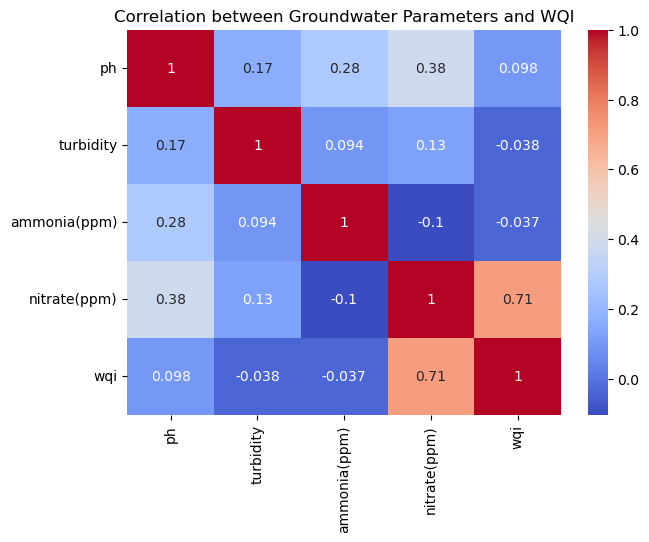

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Groundwater Parameters and WQI")
plt.show()
#"pH": 8.5,
    
 #   "Chloride (ppm)": 250,
  #  "Sulphates(ppm)": 200,
   # "Nitrate(ppm)": 45,
    #"Fluorides(ppm)": 1.5,
    #"Iron (ppm)": 0.3
#}

In [117]:
print(df_wqi.columns.tolist())

['site', 'year', 'ph', 'odour', 'turbidity', 'conductivity', 'chloride_(ppm)', 'sulphates(ppm)', 'iron_(ppm)', 'cod(ppm)', 'bod(ppm)', 'do(ppm)', 'lead(ppm)', 'ammonia(ppm)', 'nitrate(ppm)', 'fluorides(ppm)', 'phosphates(ppm)', 'total_bacterial_count_(cfu/ml)', 'total_fungal_count_(cfu/ml)', 'pesticide_(µg/l)', 'wqi']


In [118]:
bis_limits = {
    'ph': (6.5,8.5), 
    'turbidity': 5, 
    'ammonia(ppm)': 0.5, 
    'nitrate(ppm)': 45, 
    
}
exceed = {}

for p, limit in bis_limits.items():
    if p not in df_wqi.columns:
        print(f"Skipping {p} — not in dataset")
        continue

    if isinstance(limit, tuple):
        exceed[p] = ((df_wqi[p] < limit[0]) | (df_wqi[p] > limit[1])).mean()
    else:
        exceed[p] = (df_wqi[p] > limit).mean()

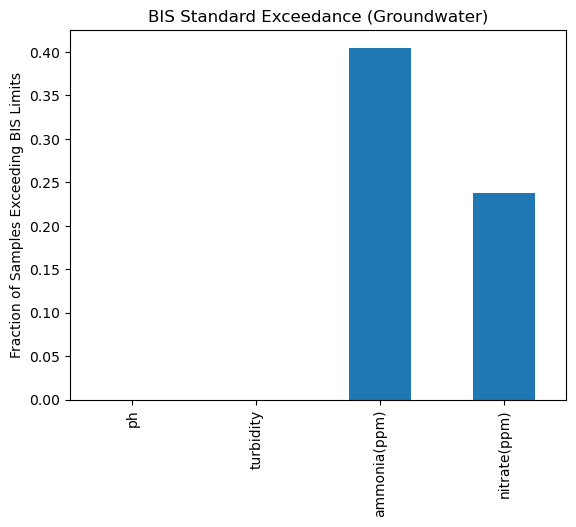

In [119]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

pd.Series(exceed).plot(kind='bar')
plt.ylabel("Fraction of Samples Exceeding BIS Limits")
plt.title("BIS Standard Exceedance (Groundwater)")
plt.show()
#This plot shows the proportion of groundwater samples exceeding BIS permissible limits, highlighting parameters that pose the greatest compliance risk.

In [120]:
#email alert code
import smtplib
from email.mime.text import MIMEText

def send_alert(email, site, wqi):
    msg = MIMEText(f"Alert: Groundwater WQI at {site} is {wqi}, indicating high risk.")
    msg['Subject'] = "Groundwater Quality Alert"
    msg['From'] = "monitoring.system@email.com"
    msg['To'] = email

    server = smtplib.SMTP('smtp.gmail.com', 587)
    server.starttls()
    server.login("your_email@gmail.com", "app_password")
    server.send_message(msg)
    server.quit()
    print("Alert email sent.")

In [121]:
try:
    send_alert("test@email.com", "Karan Lake", 280)
    print("Email function executed without error.")
except Exception as e:
    print("Email failed:", e)
#The email alert function executes silently. If credentials and connectivity are correct, the alert is sent. 
#No console output is expected unless an error occurs.

Email failed: (535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 41be03b00d2f7-c5edf2330e0sm3296229a12.7 - gsmtp')


In [122]:
X        # feature matrix (parameters)
y_reg   # target WQI (numeric)
y_cls  # WQI class (Excellent/Good etc)

0           Poor
1           Poor
2           Poor
3           Poor
4      Very Poor
5      Very Poor
6           Poor
7           Poor
8           Poor
9           Good
10          Good
11          Good
12          Poor
13          Poor
14     Very Poor
15     Very Poor
16     Very Poor
17     Very Poor
18     Very Poor
19    Unsuitable
20    Unsuitable
21          Good
22          Poor
23          Poor
24          Poor
25     Very Poor
26     Very Poor
27          Poor
28          Poor
29          Poor
30          Poor
31          Poor
32          Poor
33    Unsuitable
34    Unsuitable
35    Unsuitable
36    Unsuitable
37    Unsuitable
38    Unsuitable
39    Unsuitable
40    Unsuitable
41    Unsuitable
Name: wqi_class, dtype: object

In [156]:
#Regression
Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.2)

reg = RandomForestRegressor(n_estimators=300)
reg.fit(Xtr, ytr)

RandomForestRegressor(n_estimators=300)

In [157]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

In [158]:
y_pred = reg.predict(X_test)   # reg = trained regressor

In [159]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def NSE(obs, sim):
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)

nse = NSE(y_test.values, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("NSE:", nse)

R²: 0.9828671879964044
RMSE: 88.3048024141612
NSE: 0.9828671879964044


In [160]:
print(len(y_test), len(y_pred))

9 9


In [161]:
#K Fold Validation
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(reg, X, y_reg, cv=kf, scoring='r2')

print("5-Fold CV R²:", cv_r2.mean())

5-Fold CV R²: 0.13729348983502593


In [128]:
#K Fold Validation
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_r2 = cross_val_score(reg, X, y_reg, cv=kf, scoring='r2')

print("10-Fold CV R²:", cv_r2.mean())

10-Fold CV R²: -0.22540327392118348


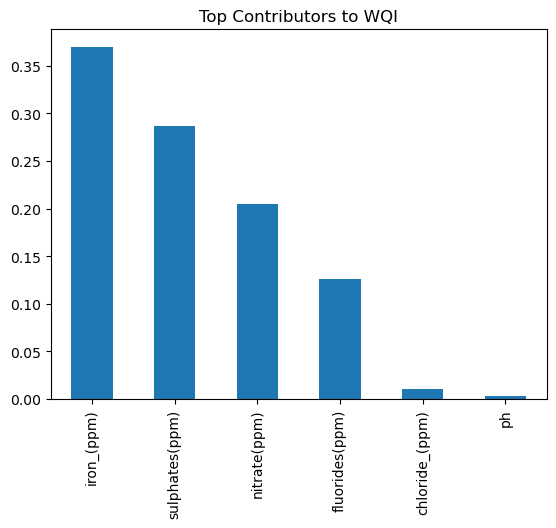

In [129]:
#FEATURE IMPORTANCE
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='bar')
plt.title("Top Contributors to WQI")
plt.show()

In [131]:
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, confusion_matrix

y_pred_cls = cls.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("F1:", f1_score(y_test_cls, y_pred_cls, average='weighted'))
print("MCC:", matthews_corrcoef(y_test_cls, y_pred_cls))
print(confusion_matrix(y_test_cls, y_pred_cls))

Accuracy: 0.5555555555555556
F1: 0.47138047138047134
MCC: 0.3038218101251
[[4 0 0]
 [0 1 1]
 [3 0 0]]


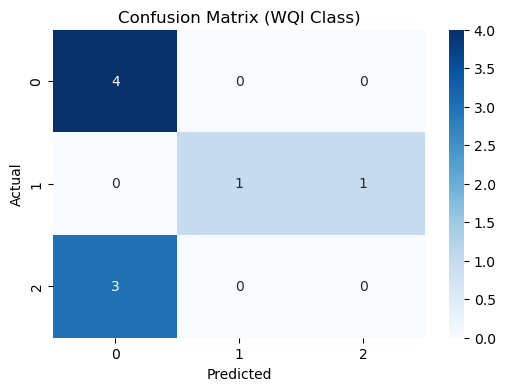

Accuracy: 0.5555555555555556
F1-score: 0.47138047138047134
MCC: 0.3038218101251
              precision    recall  f1-score   support

        Poor       0.57      1.00      0.73         4
  Unsuitable       1.00      0.50      0.67         2
   Very Poor       0.00      0.00      0.00         3

    accuracy                           0.56         9
   macro avg       0.52      0.50      0.46         9
weighted avg       0.48      0.56      0.47         9



In [132]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (WQI Class)")
plt.show()

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("F1-score:", f1_score(y_test_cls, y_pred_cls, average="weighted"))
print("MCC:", matthews_corrcoef(y_test_cls, y_pred_cls))

print(classification_report(y_test_cls, y_pred_cls))

In [133]:
print(clean.columns.tolist())

['site', 'year', 'ph', 'odour', 'turbidity', 'conductivity', 'chloride_(ppm)', 'sulphates(ppm)', 'iron_(ppm)', 'cod(ppm)', 'bod(ppm)', 'do(ppm)', 'lead(ppm)', 'ammonia(ppm)', 'nitrate(ppm)', 'fluorides(ppm)', 'phosphates(ppm)', 'total_bacterial_count_(cfu/ml)', 'total_fungal_count_(cfu/ml)', 'pesticide_(µg/l)']


In [134]:
import plotly.express as px

fig = px.scatter_3d(
    df_wqi,
    x='ph',
    y='turbidity',
    z='wqi',
    color='wqi',
    title='Interactive 3D: pH–Turbidity–WQI'
)

fig.show()

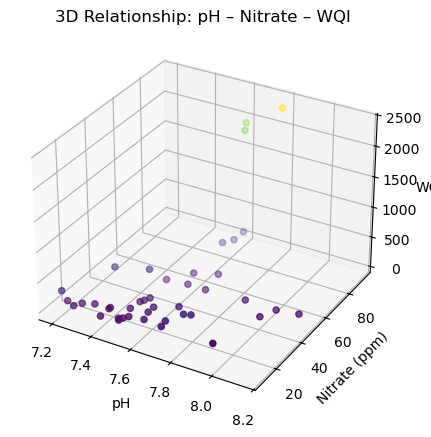

In [135]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_wqi['ph'],
    df_wqi['nitrate(ppm)'],
    df_wqi['wqi'],
    c=df_wqi['wqi'], cmap='viridis'
)

ax.set_xlabel('pH')
ax.set_ylabel('Nitrate (ppm)')
ax.set_zlabel('WQI')
ax.set_title('3D Relationship: pH – Nitrate – WQI')

plt.show()

In [150]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [151]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, epsilon=0.1))
])

In [153]:
#BUILD THE ENSEMBLER
ensemble = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('gbr', gbr),
        ('svr', svr)
    ]
)

In [154]:
#Train the Ensembler
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def NSE(obs, sim):
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)

r2 = r2_score(y_test, y_pred_ens)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ens))
nse = NSE(y_test.values, y_pred_ens)

print("Ensemble R²:", r2)
print("Ensemble RMSE:", rmse)
print("Ensemble NSE:", nse)

In [140]:
#CLASSIFICATION METRICS
# To build a results table for multiple classifiers
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef
)

results = []

def evaluate_classifier(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-score": f1_score(y_test, y_pred, average='weighted'),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

# Example models (use the ones you already trained)
results.append(evaluate_classifier("Random Forest", cls, X_test_cls, y_test_cls))
#results.append(evaluate_classifier("SVM", svm_clf, X_test_cls, y_test_cls))
results.append(evaluate_classifier("Logistic Regression", cls, X_test_cls, y_test_cls))

metrics_df = pd.DataFrame(results)
metrics_df

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,Random Forest,0.555556,0.47619,0.555556,0.47138,0.303822
1,Logistic Regression,0.555556,0.47619,0.555556,0.47138,0.303822


In [145]:
#REGRESSION METRICS
#Regression Metrics Table
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def NSE(obs, sim):
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)

reg_results = []

def evaluate_regressor(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "NSE": NSE(y_test.values, y_pred)
    }

reg_results.append(evaluate_regressor("Random Forest", reg, X_test, y_test))
#reg_results.append(evaluate_regressor("Gradient Boosting", reg, X_test, y_test))

reg_metrics_df = pd.DataFrame(reg_results)
reg_metrics_df

,Model,R2,RMSE,NSE
0,Random Forest,0.952091,147.665276,0.952091


In [155]:
metrics_df.to_csv("gclassification_metrics.csv", index=False)
reg_metrics_df.to_csv("gregression_metrics.csv", index=False)